# Prédiction du succès des campagnes publicitaires depuis PostgreSQL

Ce notebook construit un projet complet de data science à partir des tables PostgreSQL `fact_campaign` et `FactCampaign` de la base `pi_bi`.

Objectifs couverts dans le notebook :
- préparation et nettoyage des données
- feature engineering et sélection de variables
- classification du succès ou de l'échec d'une campagne
- régression sur un KPI numérique
- clustering non supervisé
- analyse temporelle si une colonne date exploitable existe
- comparaison et interprétation business des résultats

## Plan de travail

1. Connexion PostgreSQL avec gestion d'erreurs.
2. Chargement direct des deux tables dans des DataFrames pandas.
3. Exploration, nettoyage et feature engineering.
4. Modélisation supervisée pour la classification et la régression.
5. Clustering et, si possible, forecasting sur série temporelle.
6. Synthèse business finale.

In [30]:
from __future__ import annotations

import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg
import seaborn as sns
import statsmodels.api as sm
from IPython.display import Markdown, display
from sklearn.cluster import DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import RFE, SelectFromModel, SelectKBest, mutual_info_classif, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    davies_bouldin_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

import pg_connect

importlib.reload(pg_connect)

try:
    from xgboost import XGBClassifier, XGBRegressor
except Exception:
    XGBClassifier = None
    XGBRegressor = None

from pg_connect import DbConfig, get_connection, load_table, test_connection

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

In [31]:
def safe_load_table(connection: psycopg.Connection, table_name: str, schema_name: str = 'public') -> pd.DataFrame:
    """Charge une relation en gérant proprement les erreurs de lecture."""
    try:
        return load_table(connection, table_name, schema_name=schema_name)
    except Exception as error:
        print(f"Chargement impossible pour '{schema_name}.{table_name}': {error}")
        return pd.DataFrame()


def available_tables(connection: psycopg.Connection) -> pd.DataFrame:
    """Retourne les tables et vues disponibles dans la base."""
    query = """
        SELECT table_schema, table_name, table_type
        FROM information_schema.tables
        WHERE table_schema NOT IN ('pg_catalog', 'information_schema')
        ORDER BY table_schema, table_name;
    """
    with connection.cursor() as cursor:
        cursor.execute(query)
        rows = cursor.fetchall()
    return pd.DataFrame(rows, columns=['table_schema', 'table_name', 'table_type'])


def find_best_table_name(connection: psycopg.Connection, candidates: list[str]) -> tuple[str, str] | None:
    """Trouve la première relation existante parmi une liste de candidats."""
    tables_frame = available_tables(connection)
    if tables_frame.empty:
        return None

    tables_frame = tables_frame.assign(
        schema_lower=tables_frame['table_schema'].str.lower(),
        table_lower=tables_frame['table_name'].str.lower(),
    )

    for candidate in candidates:
        candidate_lower = candidate.lower()
        exact_match = tables_frame[tables_frame['table_lower'] == candidate_lower]
        if not exact_match.empty:
            row = exact_match.iloc[0]
            return row['table_schema'], row['table_name']

    for _, row in tables_frame.iterrows():
        relation_name = row['table_name'].lower()
        if any(candidate.lower() in relation_name or relation_name in candidate.lower() for candidate in candidates):
            return row['table_schema'], row['table_name']

    return None


def load_first_available_table(connection: psycopg.Connection, candidates: list[str]) -> tuple[pd.DataFrame, tuple[str, str] | None]:
    """Charge la première relation existante parmi les candidats fournis."""
    relation = find_best_table_name(connection, candidates)
    if relation is None:
        return pd.DataFrame(), None

    schema_name, table_name = relation
    return safe_load_table(connection, table_name, schema_name=schema_name), relation

In [33]:
def normalize_campaign_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Normalise les colonnes de campagne pour faciliter l'EDA et la modelisation."""
    result = df.copy()

    if result.empty:
        return result

    if 'date_pk' in result.columns:
        result['campaign_date'] = pd.to_datetime(result['date_pk'].astype(str), format='%Y%m%d', errors='coerce')

    numeric_like_columns = ['reach', 'impressions', 'frequency', 'result', 'views']
    for column_name in numeric_like_columns:
        if column_name in result.columns:
            result[column_name] = pd.to_numeric(
                result[column_name].astype(str).str.replace(r'[^0-9,.-]', '', regex=True).str.replace(',', '.', regex=False),
                errors='coerce',
            )

    if 'price' in result.columns:
        result['price'] = pd.to_numeric(
            result['price'].astype(str).str.replace(r'[^0-9,.-]', '', regex=True).str.replace(',', '.', regex=False),
            errors='coerce',
        )

    if 'documentpk' in result.columns:
        result['documentpk'] = pd.to_numeric(result['documentpk'], errors='coerce')

    return result

In [39]:
connection_ok = test_connection(DbConfig())

if connection_ok:
    connection = get_connection()
    try:
        df_fact_campaign, relation_fact_campaign = load_first_available_table(connection, ['fact_campaign'])
        df_FactCampaign, relation_FactCampaign = load_first_available_table(connection, ['FactCampaign', 'factcampaign'])
    finally:
        connection.close()
else:
    df_fact_campaign = pd.DataFrame()
    df_FactCampaign = pd.DataFrame()
    relation_fact_campaign = None
    relation_FactCampaign = None

df_frames_to_merge = [frame for frame in [df_fact_campaign, df_FactCampaign] if not frame.empty]
if df_frames_to_merge:
    df_raw = pd.concat(df_frames_to_merge, ignore_index=True, sort=False).drop_duplicates().reset_index(drop=True)
    loaded_relations = [relation for relation in [relation_fact_campaign, relation_FactCampaign] if relation is not None]
else:
    df_raw = pd.DataFrame()
    loaded_relations = []

if not df_raw.empty:
    df_raw.columns = [str(column).strip().lower() for column in df_raw.columns]
    df_raw = normalize_campaign_dataframe(df_raw)
    df_raw, target_source, target_threshold, target_rule = build_target_column(df_raw)
else:
    target_source = None
    target_threshold = None
    target_rule = 'empty_dataset'

print('Loaded relation fact_campaign:', relation_fact_campaign if relation_fact_campaign is not None else 'none')
print('Loaded relation FactCampaign:', relation_FactCampaign if relation_FactCampaign is not None else 'none')
print('fact_campaign shape:', df_fact_campaign.shape)
print('FactCampaign shape:', df_FactCampaign.shape)
print('Combined shape:', df_raw.shape)
print(f'target_rule: {target_rule}')
if target_source is not None:
    if target_threshold is None:
        print(f'target construit a partir de: {target_source}')
    else:
        print(f'target construit a partir de: {target_source} avec seuil median = {target_threshold:.4f}')

if not df_raw.empty:
    display(df_raw.head())
    print('Distribution de target:')
    display(df_raw['target'].value_counts(dropna=False).to_frame(name='count'))
else:
    if connection_ok:
        with get_connection() as tmp_connection:
            available_relations = available_tables(tmp_connection)
            if available_relations.empty:
                print('Aucune table ou vue accessible n\'a ete trouvee dans la base.')
            else:
                print('Relations disponibles dans la base:')
                display(available_relations)

Connexion reussie a PostgreSQL.
Attention: connexion sans SSL (serveur local sans TLS).
Version du serveur: PostgreSQL 15.15, compiled by Visual C++ build 1944, 64-bit
Loaded relation fact_campaign: ('datawarehouse', 'fact_campaign')
Loaded relation FactCampaign: ('datawarehouse', 'FactCampaign')
fact_campaign shape: (91, 8)
FactCampaign shape: (80, 9)
Combined shape: (171, 13)
target_rule: median_fallback
target construit a partir de: date_pk avec seuil median = 20250812.0000


,date_pk,documentpk,reach,impressions,frequency,result,price,views,factcampaignpk,datefk,documentfk,campaign_date,target
0,20250211.0,1430.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,NaT,0
1,20250211.0,1431.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,NaT,0
2,20250211.0,1432.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,NaT,0
3,20250211.0,1433.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,NaT,0
4,20250211.0,1434.0,0,0,0.0,0,3.0,0.0,NaN,NaN,NaN,NaT,0


Distribution de target:


,count
target,
0,126
1,45


## Analyse exploratoire des données

Cette section couvre la découverte de la structure, les statistiques descriptives, l'analyse des valeurs manquantes et la visualisation des distributions pour repérer les variables atypiques.

In [40]:
if df_raw.empty:
    print('Aucune donnée disponible pour l''EDA.')
else:
    print('Apercu de la structure du DataFrame:')
    display(pd.DataFrame({
        'dtype': df_raw.dtypes.astype(str),
        'non_null_count': df_raw.notna().sum(),
        'missing_count': df_raw.isna().sum(),
        'missing_pct': (df_raw.isna().mean() * 100).round(2),
        'n_unique': df_raw.nunique(dropna=False),
    }).sort_values('missing_pct', ascending=False))

    print('Apercu statistique complet avec describe():')
    display(df_raw.describe(include='all').transpose())

    print('Apercu des premieres lignes:')
    display(df_raw.head(10))

    print('Types de donnees par colonne:')
    display(df_raw.dtypes.astype(str).to_frame(name='dtype'))

Apercu de la structure du DataFrame:


,dtype,non_null_count,missing_count,missing_pct,n_unique
campaign_date,datetime64[ns],0,171,100.00,1
documentfk,float64,80,91,53.22,69
datefk,float64,80,91,53.22,13
factcampaignpk,float64,80,91,53.22,81
date_pk,float64,91,80,46.78,23
documentpk,float64,91,80,46.78,80
frequency,float64,171,0,0.00,63
reach,int64,171,0,0.00,65
impressions,int64,171,0,0.00,67
views,float64,171,0,0.00,41


Apercu statistique complet avec describe():


,count,mean,min,25%,50%,75%,max,std
date_pk,91.0,20250668.351648,20250103.0,20250670.0,20250812.0,20250814.0,20250922.0,242.733021
documentpk,91.0,1468.362637,1430.0,1452.5,1467.0,1485.5,1508.0,21.492901
reach,171.0,1000.245614,0.0,22.0,1073.0,1695.0,4694.0,985.165557
impressions,171.0,1079.450292,0.0,23.5,1109.0,1858.0,5649.0,1102.804698
frequency,171.0,0.830292,0.0,1.0,1.034856,1.052823,1.265617,0.440701
result,171.0,0.865497,0.0,0.0,0.0,1.0,10.0,1.680172
price,171.0,16.302807,0.0,0.51,1.02,1.855,300.0,57.215611
views,171.0,36.325995,0.0,0.0,43.478261,53.846154,100.0,29.046527
factcampaignpk,80.0,49.7125,1.0,31.75,51.5,71.25,91.0,26.037555
datefk,80.0,20250708.2375,20250211.0,20250725.5,20250814.0,20250814.0,20250814.0,213.297216


Apercu des premieres lignes:


,date_pk,documentpk,reach,impressions,frequency,result,price,views,factcampaignpk,datefk,documentfk,campaign_date,target
0,20250211.0,1430.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,NaT,0
1,20250211.0,1431.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,NaT,0
2,20250211.0,1432.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,NaT,0
3,20250211.0,1433.0,0,0,0.0,0,2.0,0.0,NaN,NaN,NaN,NaT,0
4,20250211.0,1434.0,0,0,0.0,0,3.0,0.0,NaN,NaN,NaN,NaT,0
5,20250212.0,1435.0,0,0,0.0,0,5.0,0.0,NaN,NaN,NaN,NaT,0
6,20250212.0,1436.0,0,0,0.0,0,5.0,0.0,NaN,NaN,NaN,NaT,0
7,20250212.0,1437.0,0,0,0.0,0,8.0,0.0,NaN,NaN,NaN,NaT,0
8,20250214.0,1438.0,0,0,0.0,0,12.0,0.0,NaN,NaN,NaN,NaT,0
9,20250215.0,1439.0,0,0,0.0,0,18.0,0.0,NaN,NaN,NaN,NaT,0


Types de donnees par colonne:


,dtype
date_pk,float64
documentpk,float64
reach,int64
impressions,int64
frequency,float64
result,int64
price,float64
views,float64
factcampaignpk,float64
datefk,float64


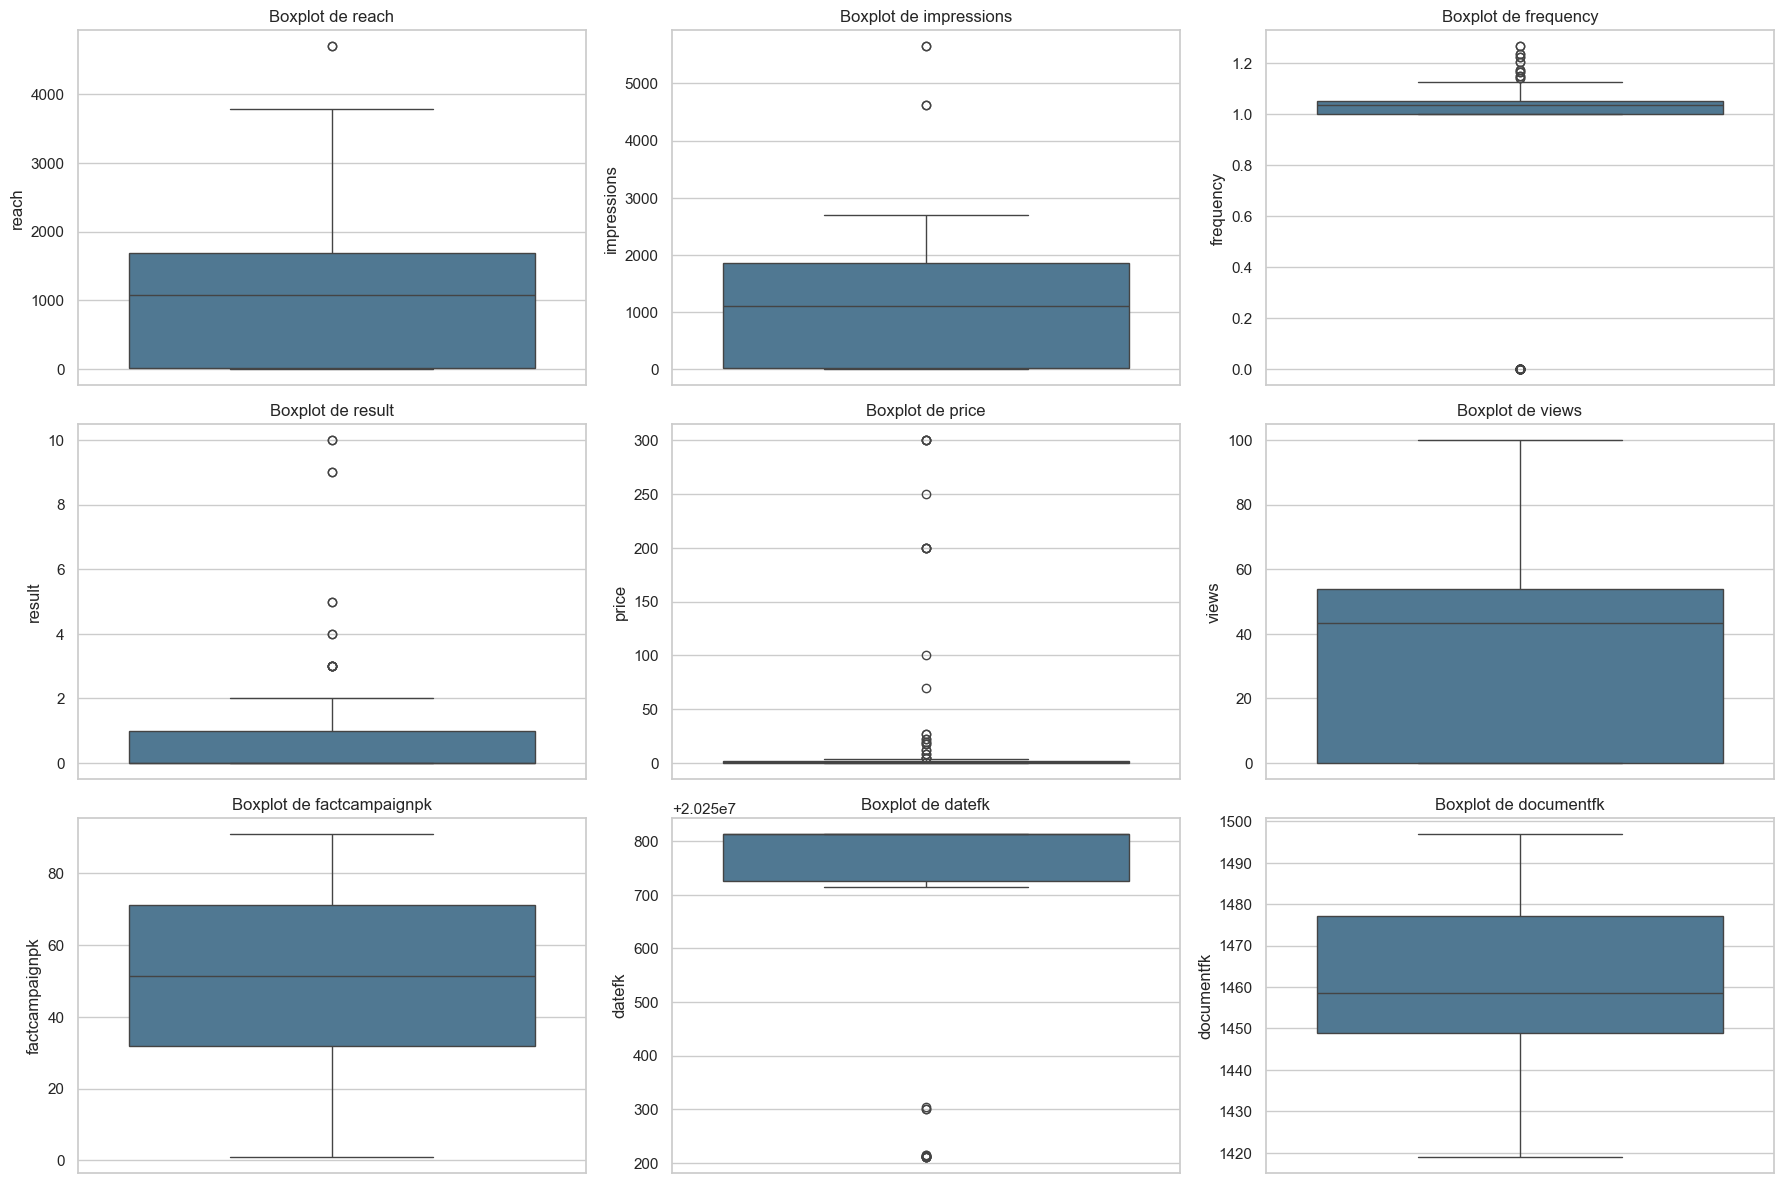

Colonnes numeriques analysees pour les boxplots:
reach, impressions, frequency, result, price, views, factcampaignpk, datefk, documentfk


In [41]:
if df_raw.empty:
    print('Aucun boxplot a generer car le DataFrame est vide.')
else:
    excluded_columns = {'target', 'documentpk', 'date_pk'}
    numeric_columns = [
        column_name
        for column_name in df_raw.select_dtypes(include=np.number).columns.tolist()
        if column_name not in excluded_columns and df_raw[column_name].nunique(dropna=True) > 2
    ]

    if not numeric_columns:
        print('Aucune colonne numerique exploitable disponible pour les boxplots.')
    else:
        n_columns = 3
        n_rows = int(np.ceil(len(numeric_columns) / n_columns))
        fig, axes = plt.subplots(n_rows, n_columns, figsize=(18, max(4, 4 * n_rows)))
        axes = np.array(axes).reshape(-1)

        for axis, column_name in zip(axes, numeric_columns):
            sns.boxplot(y=df_raw[column_name], ax=axis, color='#457b9d')
            axis.set_title(f'Boxplot de {column_name}')
            axis.set_xlabel('')

        for axis in axes[len(numeric_columns):]:
            axis.axis('off')

        plt.tight_layout()
        plt.show()

        print('Colonnes numeriques analysees pour les boxplots:')
        print(', '.join(numeric_columns))

## Matrice de corrélation

La matrice de corrélation aide à repérer les liens linéaires entre les variables numériques et à identifier les variables potentiellement redondantes.

,date_pk,documentpk,reach,impressions,frequency,result,price,views,factcampaignpk,datefk,documentfk,target
date_pk,1.000000,0.726284,0.491526,0.467224,0.900167,0.240506,-0.432666,0.619483,NaN,NaN,NaN,0.606599
documentpk,0.726284,1.000000,0.243309,0.228145,0.736852,-0.006230,-0.347647,0.491532,NaN,NaN,NaN,0.621793
reach,0.491526,0.243309,1.000000,0.995092,0.576785,0.591877,-0.267147,0.395849,0.077937,0.433084,0.134997,0.079537
impressions,0.467224,0.228145,0.995092,1.000000,0.566455,0.628633,-0.256738,0.391898,0.068522,0.406530,0.121919,0.049322
frequency,0.900167,0.736852,0.576785,0.566455,1.000000,0.329171,-0.511051,0.670034,0.700434,0.964745,0.705636,0.244375
result,0.240506,-0.006230,0.591877,0.628633,0.329171,1.000000,-0.132666,0.314678,-0.081288,0.195777,-0.077664,-0.078856
price,-0.432666,-0.347647,-0.267147,-0.256738,-0.511051,-0.132666,1.000000,-0.338765,-0.508620,-0.647532,-0.491466,-0.118481
views,0.619483,0.491532,0.395849,0.391898,0.670034,0.314678,-0.338765,1.000000,0.362821,0.575421,0.402554,0.134918
factcampaignpk,NaN,NaN,0.077937,0.068522,0.700434,-0.081288,-0.508620,0.362821,1.000000,0.741614,0.943579,NaN
datefk,NaN,NaN,0.433084,0.406530,0.964745,0.195777,-0.647532,0.575421,0.741614,1.000000,0.737932,NaN


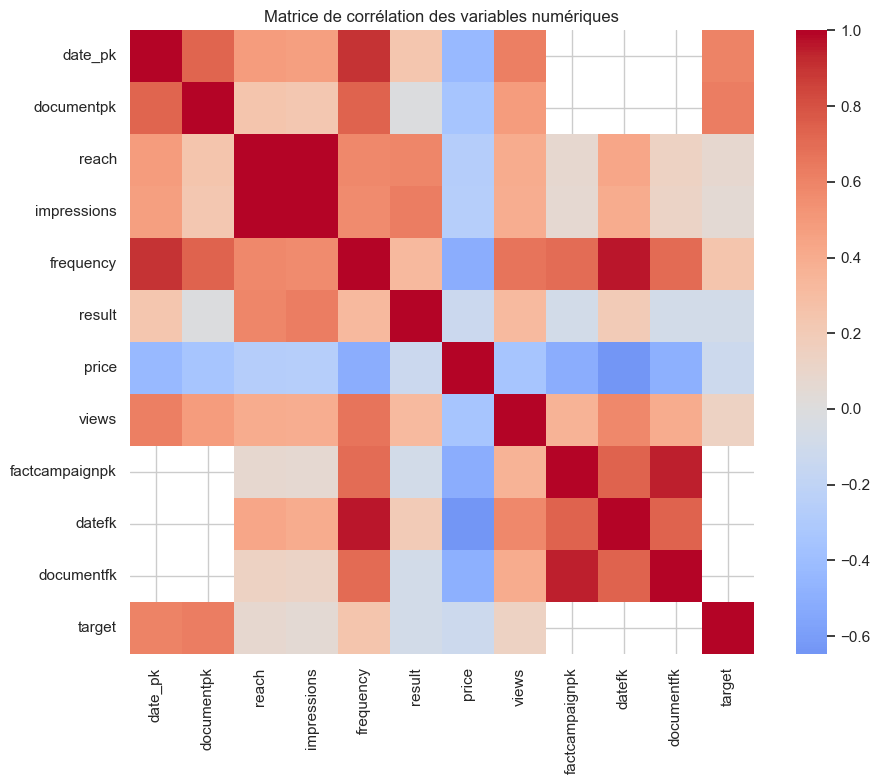

,correlation_with_target
target,1.000000
documentpk,0.621793
date_pk,0.606599
frequency,0.244375
views,0.134918
reach,0.079537
impressions,0.049322
result,-0.078856
price,-0.118481
factcampaignpk,NaN


In [48]:
if df_raw.empty:
    print('Aucune matrice de corrélation à afficher car le DataFrame est vide.')
else:
    correlation_frame = df_raw.select_dtypes(include=np.number).corr()
    display(correlation_frame)

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_frame, cmap='coolwarm', center=0, annot=False, square=True)
    plt.title('Matrice de corrélation des variables numériques')
    plt.tight_layout()
    plt.show()

    if 'target' in correlation_frame.columns:
        target_correlations = correlation_frame['target'].sort_values(ascending=False)
        display(target_correlations.to_frame(name='correlation_with_target'))

## Justification du choix des modèles

Pour la classification, la régression logistique sert de base interprétable et rapide, tandis que la forêt aléatoire capture mieux les relations non linéaires et les interactions entre variables.
Pour la régression, on compare un modèle linéaire simple avec une version régularisée pour mesurer le gain en stabilité.
Pour le clustering, K-Means fournit une segmentation lisible et DBSCAN permet de détecter des groupes de densité différente et d'éventuels points atypiques.

In [43]:
def build_model_frame(df: pd.DataFrame, target_column: str, drop_columns: list[str] | None = None) -> tuple[pd.DataFrame, pd.Series]:
    """Prépare une matrice de variables explicatives et la cible pour les modèles."""
    if drop_columns is None:
        drop_columns = []

    modeling_frame = df.copy()
    if modeling_frame.empty:
        return pd.DataFrame(), pd.Series(dtype='float64')

    if 'campaign_date' in modeling_frame.columns:
        base_date = modeling_frame['campaign_date'].min()
        modeling_frame['campaign_date_ordinal'] = (modeling_frame['campaign_date'] - base_date).dt.days

    columns_to_drop = set(drop_columns + [target_column, 'campaign_date'])
    feature_frame = modeling_frame.drop(columns=[column for column in columns_to_drop if column in modeling_frame.columns])
    feature_frame = feature_frame.select_dtypes(include=[np.number]).copy()
    target_series = modeling_frame[target_column].copy()

    return feature_frame, target_series

## C. Classification du succès

La variable `target` sert ici de cible binaire pour prédire le succès ou l'échec d'une campagne. La régression logistique offre une baseline interprétable, tandis que la forêt aléatoire capture des relations non linéaires et fournit une importance des variables exploitable.

,model,accuracy_cv,precision_cv,recall_cv,f1_cv,roc_auc_cv,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
1,Random Forest,0.914154,0.826984,0.87619,0.841204,0.966917,0.930233,1.000000,0.727273,0.842105,0.944602
0,Logistic Regression,0.852615,0.657187,1.00000,0.789353,0.839265,0.906977,0.769231,0.909091,0.833333,0.943182


Modèle classification retenu: Random Forest


,Pred 0,Pred 1
Reel 0,32,0
Reel 1,3,8


              precision    recall  f1-score   support

           0       0.91      1.00      0.96        32
           1       1.00      0.73      0.84        11

    accuracy                           0.93        43
   macro avg       0.96      0.86      0.90        43
weighted avg       0.94      0.93      0.93        43



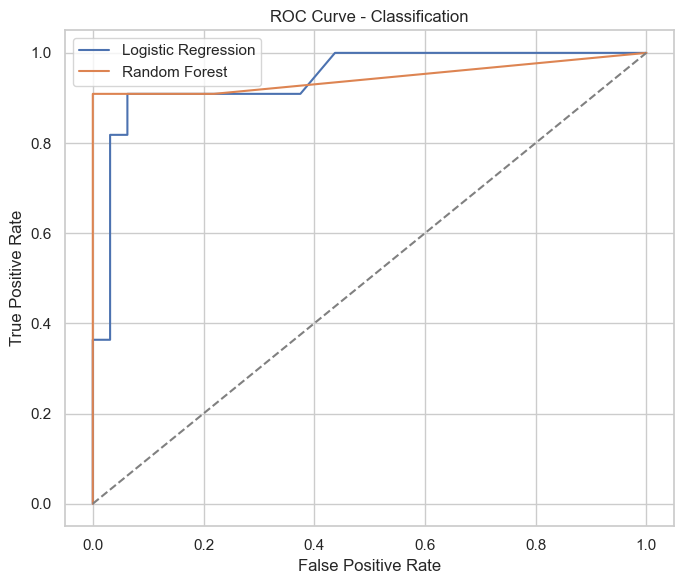

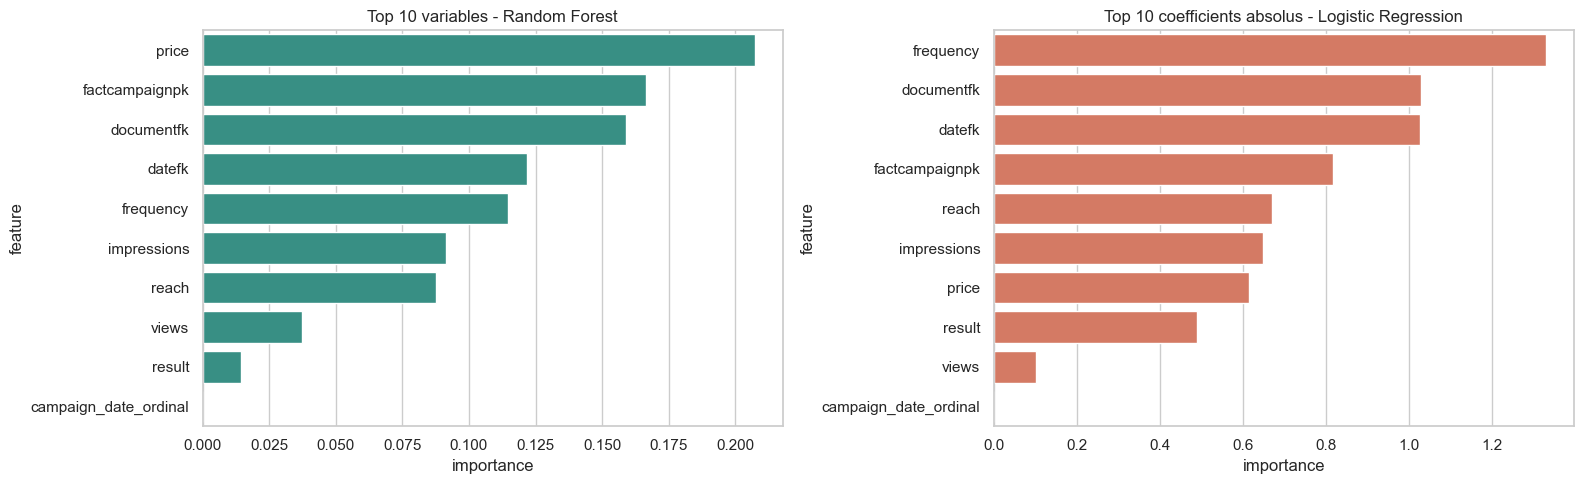

In [44]:
if df_raw.empty:
    print('Classification impossible: aucune donnée disponible.')
else:
    classification_features, y_classification = build_model_frame(df_raw, 'target', drop_columns=['date_pk', 'documentpk'])
    classification_features = classification_features.fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(
        classification_features,
        y_classification,
        test_size=0.25,
        random_state=42,
        stratify=y_classification,
    )

    classification_models = {
        'Logistic Regression': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
        ]),
        'Random Forest': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced_subsample')),
        ]),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
    }

    classification_rows = []
    fitted_classification_models = {}

    for model_name, model_pipeline in classification_models.items():
        cv_results = cross_validate(model_pipeline, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)
        model_pipeline.fit(X_train, y_train)
        fitted_classification_models[model_name] = model_pipeline

        y_pred = model_pipeline.predict(X_test)
        y_prob = model_pipeline.predict_proba(X_test)[:, 1]

        classification_rows.append({
            'model': model_name,
            'accuracy_cv': cv_results['test_accuracy'].mean(),
            'precision_cv': cv_results['test_precision'].mean(),
            'recall_cv': cv_results['test_recall'].mean(),
            'f1_cv': cv_results['test_f1'].mean(),
            'roc_auc_cv': cv_results['test_roc_auc'].mean(),
            'accuracy_test': accuracy_score(y_test, y_pred),
            'precision_test': precision_score(y_test, y_pred, zero_division=0),
            'recall_test': recall_score(y_test, y_pred, zero_division=0),
            'f1_test': f1_score(y_test, y_pred, zero_division=0),
            'roc_auc_test': roc_auc_score(y_test, y_prob),
        })

    classification_results = pd.DataFrame(classification_rows).sort_values('roc_auc_test', ascending=False)
    display(classification_results)

    best_classification_model_name = classification_results.iloc[0]['model']
    best_classification_model = fitted_classification_models[best_classification_model_name]
    y_best_pred = best_classification_model.predict(X_test)
    y_best_prob = best_classification_model.predict_proba(X_test)[:, 1]

    print(f'Modèle classification retenu: {best_classification_model_name}')
    display(pd.DataFrame(confusion_matrix(y_test, y_best_pred), index=['Reel 0', 'Reel 1'], columns=['Pred 0', 'Pred 1']))
    print(classification_report(y_test, y_best_pred, zero_division=0))

    plt.figure(figsize=(7, 6))
    for model_name, model_pipeline in fitted_classification_models.items():
        probas = model_pipeline.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probas)
        plt.plot(fpr, tpr, label=model_name)
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.title('ROC Curve - Classification')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.tight_layout()
    plt.show()

    feature_names = X_train.columns.tolist()
    rf_model = fitted_classification_models['Random Forest'].named_steps['model']
    rf_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_model.feature_importances_,
    }).sort_values('importance', ascending=False)

    logistic_model = fitted_classification_models['Logistic Regression'].named_steps['model']
    logistic_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': np.abs(logistic_model.coef_[0]),
    }).sort_values('importance', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(data=rf_importance.head(10), x='importance', y='feature', ax=axes[0], color='#2a9d8f')
    axes[0].set_title('Top 10 variables - Random Forest')
    sns.barplot(data=logistic_importance.head(10), x='importance', y='feature', ax=axes[1], color='#e76f51')
    axes[1].set_title('Top 10 coefficients absolus - Logistic Regression')
    plt.tight_layout()
    plt.show()

,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
model,,,,,
Random Forest,0.930233,1.000000,0.727273,0.842105,0.944602
Logistic Regression,0.906977,0.769231,0.909091,0.833333,0.943182


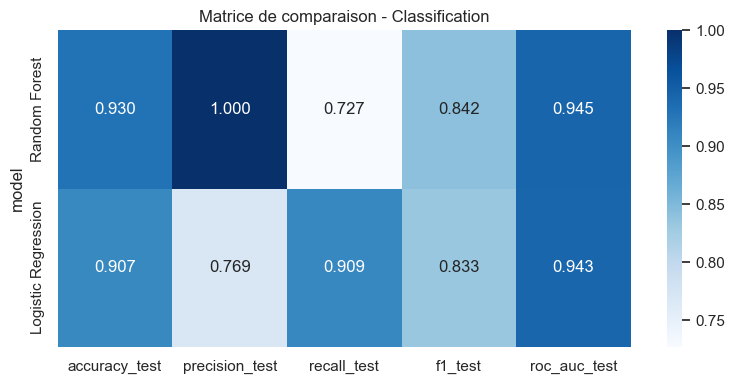

In [49]:
if 'classification_results' in globals() and not classification_results.empty:
    classification_matrix = classification_results.set_index('model')[['accuracy_test', 'precision_test', 'recall_test', 'f1_test', 'roc_auc_test']]
    display(classification_matrix)

    plt.figure(figsize=(8, 4))
    sns.heatmap(classification_matrix, annot=True, fmt='.3f', cmap='Blues')
    plt.title('Matrice de comparaison - Classification')
    plt.tight_layout()
    plt.show()
else:
    print('Matrice de comparaison classification indisponible.')

## D. Régression

La régression est appliquée à une variable numérique de performance afin de comparer un modèle linéaire simple à une version régularisée. L'objectif est d'évaluer la stabilité de la prédiction et la qualité d'ajustement.

,model,mse_cv,rmse_cv,mae_cv,r2_cv,mse_test,rmse_test,mae_test,r2_test
1,Ridge,539.467617,23.226442,15.335996,0.396073,291.329140,17.068367,11.247795,0.567128
0,Linear Regression,567.058469,23.812990,15.825387,0.359548,293.693312,17.137483,11.195404,0.563615


,mse_test,rmse_test,mae_test,r2_test
model,,,,
Ridge,291.329140,17.068367,11.247795,0.567128
Linear Regression,293.693312,17.137483,11.195404,0.563615


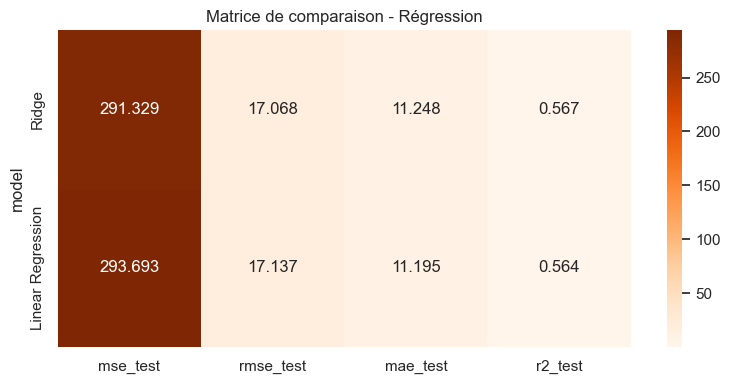

Modèle régression retenu: Ridge sur la cible views


,reel,predit
0,0.000000,2.227078
1,66.666667,51.957832
2,58.064516,77.214604
3,18.181818,40.386606
4,45.161290,38.980128
5,0.000000,47.293546
6,66.666667,52.436417
7,66.666667,53.692550
8,29.032258,47.510413
9,37.037037,46.848783


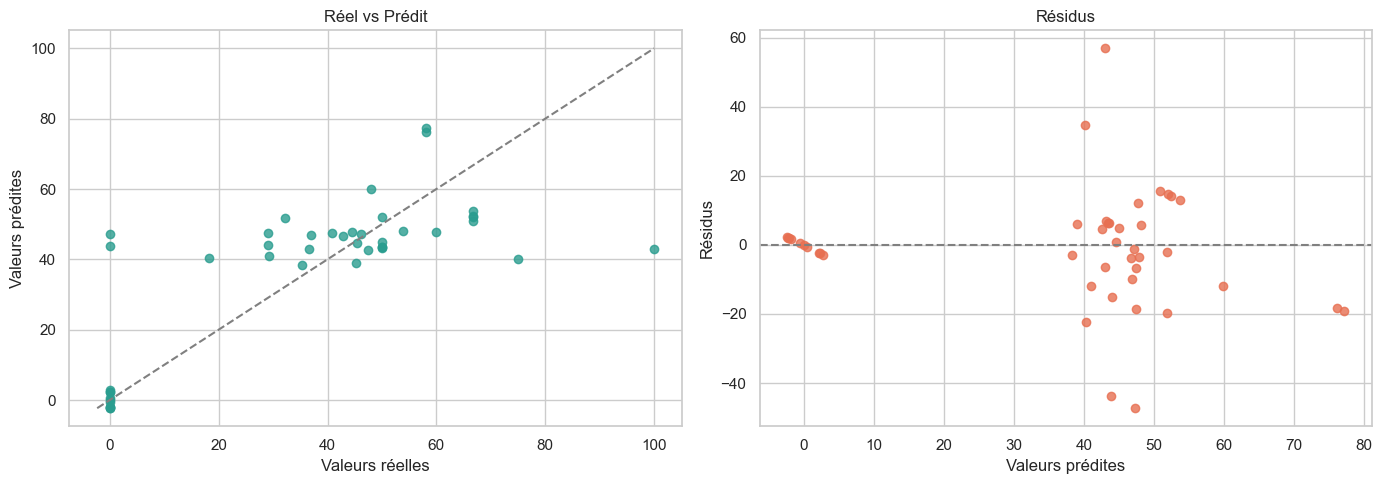

,feature,linear_coef,ridge_coef,abs_ridge_coef
2,frequency,20.775249,20.368856,20.368856
1,impressions,-14.878821,-6.107848,6.107848
3,result,5.288683,4.449102,4.449102
0,reach,11.518526,3.786576,3.786576
5,factcampaignpk,-15.986276,-3.755970,3.755970
7,documentfk,357.162603,2.338914,2.338914
8,target,-0.964915,-0.600330,0.600330
6,datefk,-344.477906,0.552390,0.552390
4,price,0.510924,0.483748,0.483748
9,campaign_date_ordinal,0.000000,0.000000,0.000000


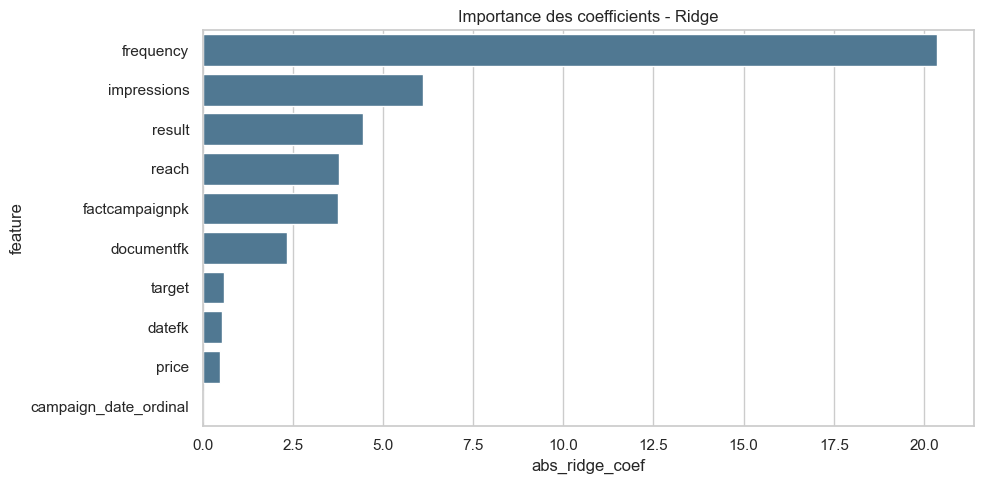

In [50]:
if df_raw.empty:
    print('Regression impossible: aucune donnée disponible.')
else:
    regression_target_column = 'views' if 'views' in df_raw.columns else 'impressions'
    regression_features, y_regression = build_model_frame(df_raw, regression_target_column, drop_columns=['date_pk', 'documentpk'])
    regression_features = regression_features.fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(
        regression_features,
        y_regression,
        test_size=0.25,
        random_state=42,
    )

    regression_models = {
        'Linear Regression': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LinearRegression()),
        ]),
        'Ridge': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=1.0)),
        ]),
    }

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    regression_rows = []
    fitted_regression_models = {}

    for model_name, model_pipeline in regression_models.items():
        cv_results = cross_validate(
            model_pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring={'mse': 'neg_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
            return_train_score=False,
        )
        model_pipeline.fit(X_train, y_train)
        fitted_regression_models[model_name] = model_pipeline
        predictions = model_pipeline.predict(X_test)

        mse_value = mean_squared_error(y_test, predictions)
        regression_rows.append({
            'model': model_name,
            'mse_cv': -cv_results['test_mse'].mean(),
            'rmse_cv': np.sqrt(-cv_results['test_mse'].mean()),
            'mae_cv': -cv_results['test_mae'].mean(),
            'r2_cv': cv_results['test_r2'].mean(),
            'mse_test': mse_value,
            'rmse_test': np.sqrt(mse_value),
            'mae_test': mean_absolute_error(y_test, predictions),
            'r2_test': r2_score(y_test, predictions),
        })

    regression_results = pd.DataFrame(regression_rows).sort_values('rmse_test')
    display(regression_results)

    regression_matrix = regression_results.set_index('model')[['mse_test', 'rmse_test', 'mae_test', 'r2_test']]
    display(regression_matrix)

    plt.figure(figsize=(8, 4))
    sns.heatmap(regression_matrix, annot=True, fmt='.3f', cmap='Oranges')
    plt.title('Matrice de comparaison - Régression')
    plt.tight_layout()
    plt.show()

    best_regression_model_name = regression_results.iloc[0]['model']
    best_regression_model = fitted_regression_models[best_regression_model_name]
    y_pred = best_regression_model.predict(X_test)
    residuals = y_test - y_pred

    print(f'Modèle régression retenu: {best_regression_model_name} sur la cible {regression_target_column}')
    comparison_frame = pd.DataFrame({'reel': y_test, 'predit': y_pred}).reset_index(drop=True)
    display(comparison_frame.head(10))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test, y_pred, alpha=0.8, color='#2a9d8f')
    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())
    axes[0].plot([min_value, max_value], [min_value, max_value], '--', color='gray')
    axes[0].set_title('Réel vs Prédit')
    axes[0].set_xlabel('Valeurs réelles')
    axes[0].set_ylabel('Valeurs prédites')

    axes[1].scatter(y_pred, residuals, alpha=0.8, color='#e76f51')
    axes[1].axhline(0, linestyle='--', color='gray')
    axes[1].set_title('Résidus')
    axes[1].set_xlabel('Valeurs prédites')
    axes[1].set_ylabel('Résidus')
    plt.tight_layout()
    plt.show()

    feature_names = X_train.columns.tolist()
    linear_model = fitted_regression_models['Linear Regression'].named_steps['model']
    ridge_model = fitted_regression_models['Ridge'].named_steps['model']

    coefficient_frame = pd.DataFrame({
        'feature': feature_names,
        'linear_coef': linear_model.coef_,
        'ridge_coef': ridge_model.coef_,
    })
    coefficient_frame['abs_ridge_coef'] = coefficient_frame['ridge_coef'].abs()
    display(coefficient_frame.sort_values('abs_ridge_coef', ascending=False).head(10))

    plt.figure(figsize=(10, 5))
    top_coefficients = coefficient_frame.sort_values('abs_ridge_coef', ascending=False).head(10)
    sns.barplot(data=top_coefficients, x='abs_ridge_coef', y='feature', color='#457b9d')
    plt.title('Importance des coefficients - Ridge')
    plt.tight_layout()
    plt.show()

## E. Clustering

Le clustering cherche à segmenter les campagnes selon leur profil numérique. K-Means donne une segmentation stable et simple à interpréter, tandis que DBSCAN détecte des formes plus irrégulières et des points isolés.

,model,clusters,silhouette,davies_bouldin
0,KMeans,6,0.502729,0.677812
1,DBSCAN,7,0.451171,0.614420


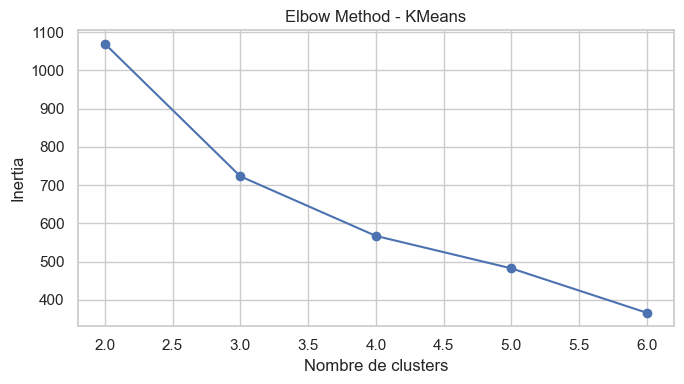

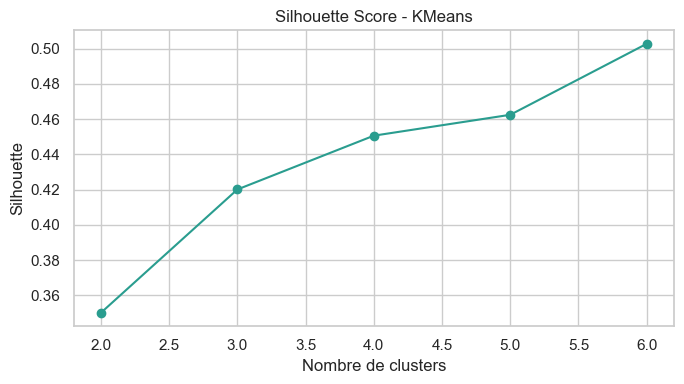

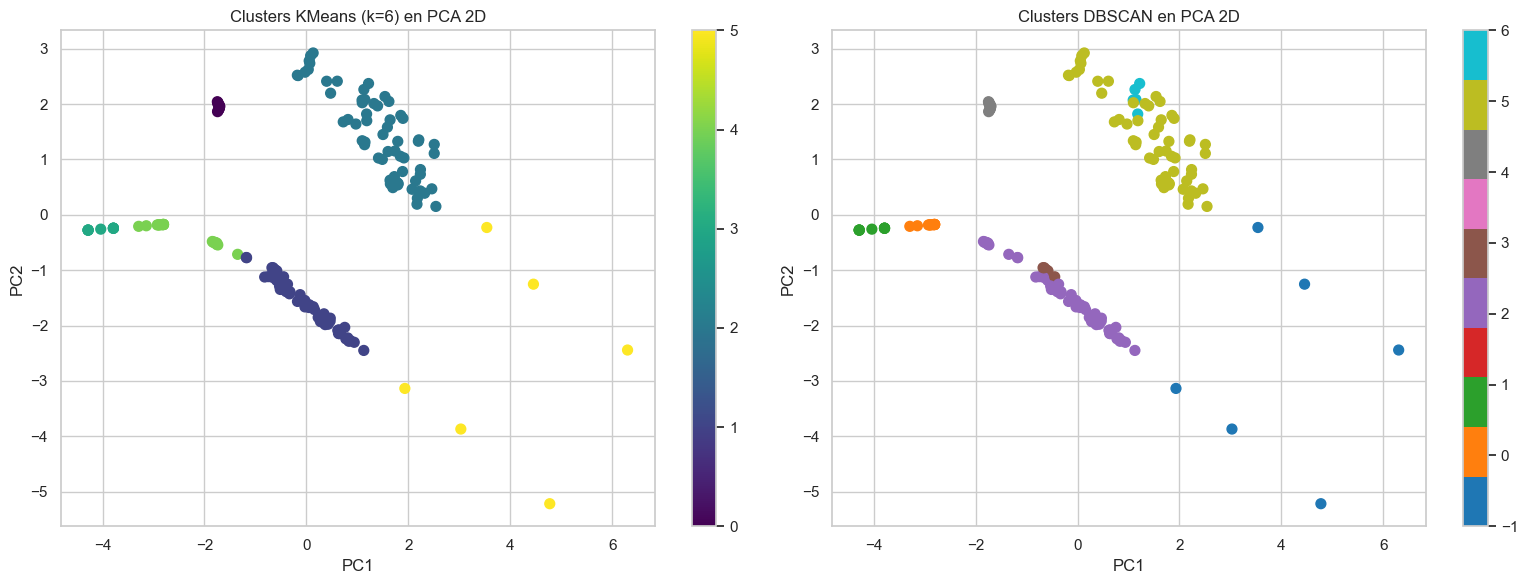

Profil moyen des clusters KMeans:


,reach,impressions,frequency,result,price,views,factcampaignpk,datefk,documentfk,campaign_date_ordinal,dbscan_cluster
kmeans_cluster,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,9.810000,0.000000,7.00000,2.025023e+07,1425.000000,0.0,4.000000
1,1363.290909,1447.000000,1.055784,0.909091,0.859273,52.857866,0.00000,0.000000e+00,0.000000,0.0,2.090909
2,1179.843750,1251.953125,1.052030,0.781250,0.738906,45.945562,58.46875,2.025080e+07,1467.468750,0.0,5.078125
3,0.000000,0.000000,0.000000,0.000000,250.000000,0.000000,0.00000,0.000000e+00,0.000000,0.0,1.000000
4,22.041667,22.500000,0.385907,0.000000,12.398333,1.388889,0.00000,0.000000e+00,0.000000,0.0,0.750000
5,3337.000000,4056.000000,1.220008,8.000000,3.023333,55.118851,24.00000,1.012538e+07,728.333333,0.0,-1.000000


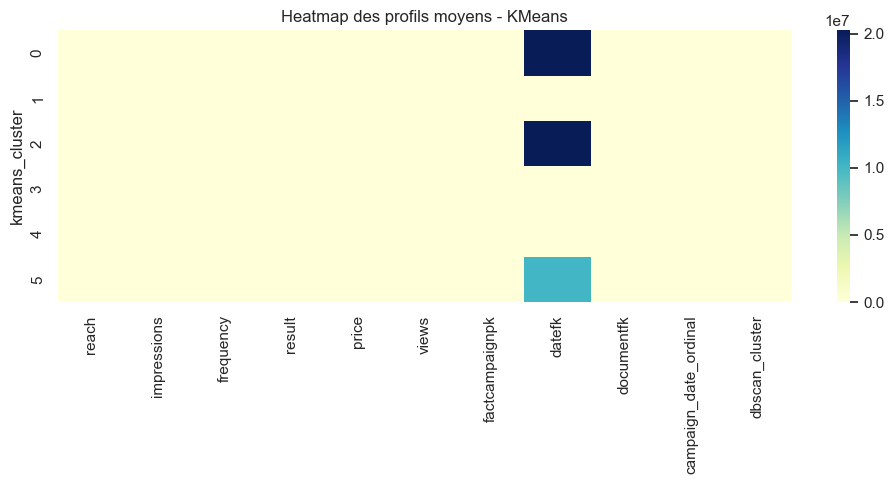

Profil moyen des clusters DBSCAN (hors bruit si présent):


,reach,impressions,frequency,result,price,views,factcampaignpk,datefk,documentfk,campaign_date_ordinal,kmeans_cluster
dbscan_cluster,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,19.835333,0.000000,0.000000,0.000000e+00,0.000000,0.0,4.000000
1,0.000000,0.000000,0.000000,0.000000,250.000000,0.000000,0.000000,0.000000e+00,0.000000,0.0,3.000000
2,1274.305085,1352.372881,1.053696,0.830508,0.801525,41.364678,0.000000,0.000000e+00,0.000000,0.0,1.457627
3,65.200000,67.000000,1.032368,0.200000,0.000000,100.000000,0.000000,0.000000e+00,0.000000,0.0,1.000000
4,0.000000,0.000000,0.000000,0.000000,9.810000,0.000000,7.000000,2.025023e+07,1425.000000,0.0,0.000000
5,1274.305085,1352.372881,1.053696,0.830508,0.801525,41.364678,57.389831,2.025080e+07,1466.457627,0.0,2.000000
6,65.200000,67.000000,1.032368,0.200000,0.000000,100.000000,71.200000,2.025081e+07,1479.400000,0.0,2.000000


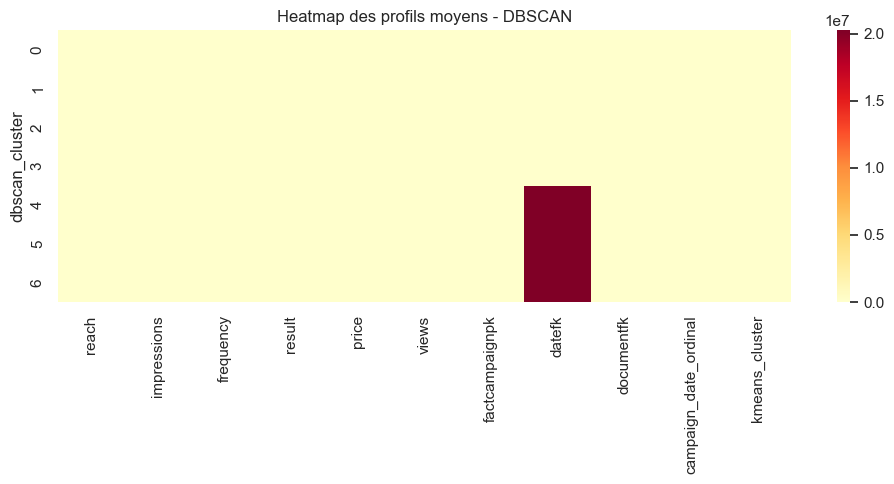

In [46]:
if df_raw.empty:
    print('Clustering impossible: aucune donnée disponible.')
else:
    cluster_features, _ = build_model_frame(df_raw, 'target', drop_columns=['date_pk', 'documentpk'])
    cluster_features = cluster_features.fillna(0)

    scaler = StandardScaler()
    cluster_scaled = scaler.fit_transform(cluster_features)

    k_values = range(2, 7)
    elbow_inertia = []
    kmeans_silhouette = []
    kmeans_models = {}

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(cluster_scaled)
        kmeans_models[k] = kmeans
        elbow_inertia.append(kmeans.inertia_)
        if len(np.unique(labels)) > 1:
            kmeans_silhouette.append(silhouette_score(cluster_scaled, labels))
        else:
            kmeans_silhouette.append(np.nan)

    best_k = int(pd.Series(kmeans_silhouette, index=list(k_values)).idxmax())
    best_kmeans = kmeans_models[best_k]
    kmeans_labels = best_kmeans.fit_predict(cluster_scaled)
    kmeans_silhouette_value = silhouette_score(cluster_scaled, kmeans_labels)
    kmeans_db_index = davies_bouldin_score(cluster_scaled, kmeans_labels)

    dbscan = DBSCAN(eps=1.2, min_samples=4)
    dbscan_labels = dbscan.fit_predict(cluster_scaled)
    dbscan_cluster_count = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    dbscan_silhouette_value = silhouette_score(cluster_scaled, dbscan_labels) if dbscan_cluster_count > 1 else np.nan
    dbscan_db_index = davies_bouldin_score(cluster_scaled, dbscan_labels) if dbscan_cluster_count > 1 else np.nan

    cluster_comparison = pd.DataFrame([
        {
            'model': 'KMeans',
            'clusters': best_k,
            'silhouette': kmeans_silhouette_value,
            'davies_bouldin': kmeans_db_index,
        },
        {
            'model': 'DBSCAN',
            'clusters': dbscan_cluster_count,
            'silhouette': dbscan_silhouette_value,
            'davies_bouldin': dbscan_db_index,
        },
    ])
    display(cluster_comparison)

    plt.figure(figsize=(7, 4))
    plt.plot(list(k_values), elbow_inertia, marker='o')
    plt.title('Elbow Method - KMeans')
    plt.xlabel('Nombre de clusters')
    plt.ylabel('Inertia')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(list(k_values), kmeans_silhouette, marker='o', color='#2a9d8f')
    plt.title('Silhouette Score - KMeans')
    plt.xlabel('Nombre de clusters')
    plt.ylabel('Silhouette')
    plt.tight_layout()
    plt.show()

    pca = PCA(n_components=2, random_state=42)
    cluster_pca = pca.fit_transform(cluster_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    scatter_kmeans = axes[0].scatter(cluster_pca[:, 0], cluster_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50)
    axes[0].set_title(f'Clusters KMeans (k={best_k}) en PCA 2D')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    plt.colorbar(scatter_kmeans, ax=axes[0])

    scatter_dbscan = axes[1].scatter(cluster_pca[:, 0], cluster_pca[:, 1], c=dbscan_labels, cmap='tab10', s=50)
    axes[1].set_title('Clusters DBSCAN en PCA 2D')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    plt.colorbar(scatter_dbscan, ax=axes[1])
    plt.tight_layout()
    plt.show()

    cluster_profiles = cluster_features.copy()
    cluster_profiles['kmeans_cluster'] = kmeans_labels
    cluster_profiles['dbscan_cluster'] = dbscan_labels

    print('Profil moyen des clusters KMeans:')
    display(cluster_profiles.groupby('kmeans_cluster').mean(numeric_only=True))

    plt.figure(figsize=(10, 5))
    sns.heatmap(cluster_profiles.groupby('kmeans_cluster').mean(numeric_only=True), cmap='YlGnBu', annot=False)
    plt.title('Heatmap des profils moyens - KMeans')
    plt.tight_layout()
    plt.show()

    print('Profil moyen des clusters DBSCAN (hors bruit si présent):')
    dbscan_profiles = cluster_profiles[cluster_profiles['dbscan_cluster'] != -1].groupby('dbscan_cluster').mean(numeric_only=True)
    if not dbscan_profiles.empty:
        display(dbscan_profiles)
        plt.figure(figsize=(10, 5))
        sns.heatmap(dbscan_profiles, cmap='YlOrRd', annot=False)
        plt.title('Heatmap des profils moyens - DBSCAN')
        plt.tight_layout()
        plt.show()
    else:
        print('DBSCAN n\'a identifié aucun cluster exploitable hors bruit.')